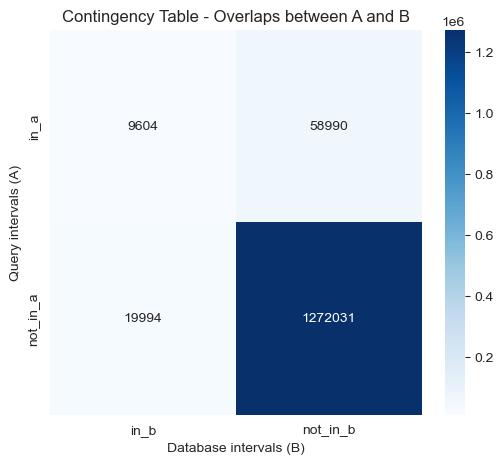

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

file_path = r"D:\SYSTEMS BIOLOGY\fisher_results.txt"

# Leggi tutte le righe
with open(file_path) as f:
    lines = f.readlines()

# Trova l'inizio della tabella
table_start = None
for i, line in enumerate(lines):
    if "in -b" in line and "not in -b" in line:
        table_start = i + 1
        break

# Leggi solo le righe che contengono numeri
data_rows = []
for r in lines[table_start:table_start+2]:  # 2 righe della contingency table
    # prendi solo le parti che sono numeri
    nums = [int(x) for x in r.strip().split() if x.isdigit()]
    data_rows.append(nums)

# Creo il DataFrame
data = pd.DataFrame(data_rows, columns=["in_b", "not_in_b"], index=["in_a", "not_in_a"])

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(data, annot=True, fmt="d", cmap="Blues")
plt.title("Contingency Table - Overlaps between A and B")
plt.ylabel("Query intervals (A)")
plt.xlabel("Database intervals (B)")
plt.show()


C:\Users\imada\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


  Comparison  OddsRatio  Pvalue  logP    log2OR
0  promoters     10.358     0.0   inf  3.372674
1  enhancers     18.154     0.0   inf  4.182216
2       CTCF    622.057     0.0   inf  9.280903
3        PLS     19.907     0.0   inf  4.315204
4       dELS      9.633     0.0   inf  3.267985
5       pELS      8.624     0.0   inf  3.108357


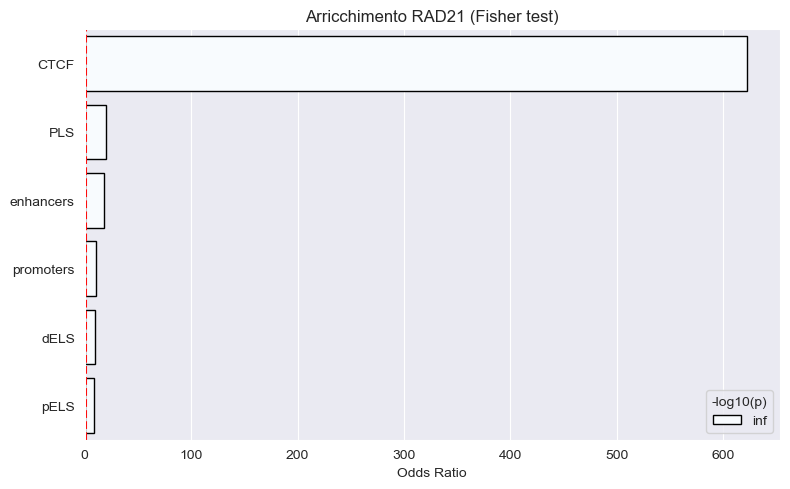

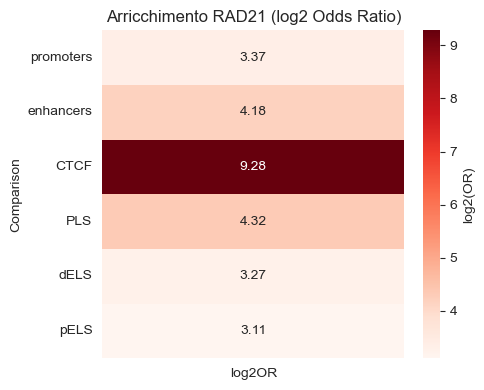

In [16]:
import os
os.chdir(r"D:\SYSTEMS BIOLOGY")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Elenco file Fisher (adatta i percorsi)
files = {
    "promoters": "fisher_RAD21_vs_promoters.txt",
    "enhancers": "fisher_RAD21_vs_enhancers.txt",
    "CTCF": "fisher_RAD21_vs_CTCF_clean.txt",
    "PLS": "fisher_RAD21_vs_PLS.txt",
    "dELS": "fisher_RAD21_vs_dELS.txt",
    "pELS": "fisher_RAD21_vs_pELS.txt"
}

# --- 2. Leggi i file Fisher
df_list = []
for name, path in files.items():
    try:
        tab = pd.read_csv(path, sep="\t", comment="#")
        if "ratio" in tab.columns and "two-tail" in tab.columns:
            odds = float(tab["ratio"].iloc[0])
            pval = float(tab["two-tail"].iloc[0])
            df_list.append({"Comparison": name, "OddsRatio": odds, "Pvalue": pval})
    except Exception as e:
        print(f"Errore con {name}: {e}")

df = pd.DataFrame(df_list)
df["logP"] = -np.log10(df["Pvalue"])
df["log2OR"] = np.log2(df["OddsRatio"])

print(df)

# --- 3. Barplot colorato
plt.figure(figsize=(8,5))
sns.barplot(data=df.sort_values("OddsRatio", ascending=False),
            x="OddsRatio", y="Comparison", hue="logP", dodge=False,
            palette="Blues", edgecolor="black",)
plt.axvline(1, ls="--", color="red")
plt.title("Arricchimento RAD21 (Fisher test)")
plt.xlabel("Odds Ratio")
plt.ylabel("")
plt.legend(title="-log10(p)", loc="lower right")
plt.tight_layout()
plt.show()

# --- 4. Heatmap log2(OR)
plt.figure(figsize=(5,4))
sns.heatmap(df.set_index("Comparison")[["log2OR"]],
            annot=True, fmt=".2f", cmap="Reds",
            cbar_kws={'label': 'log2(OR)'})
plt.title("Arricchimento RAD21 (log2 Odds Ratio)")
plt.tight_layout()

plt.show()



CSV pulito creato in: D:\SYSTEMS BIOLOGY\fisher_results_clean.csv
          DB_in  DB_not_in
Query_in   9604      58990
Query_in  19994    1272031


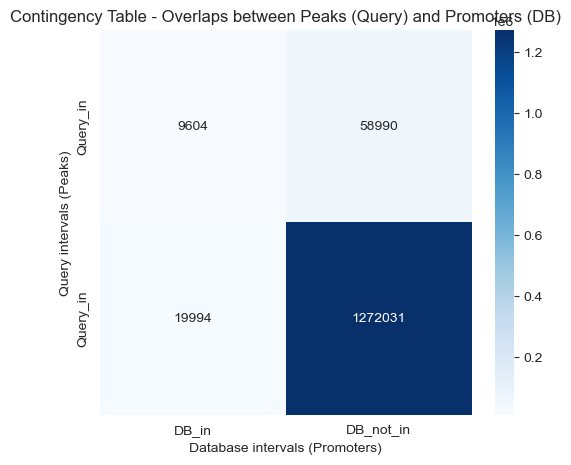

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Percorso del file originale
file_path = r"D:\SYSTEMS BIOLOGY\fisher_results.txt"

# Percorso del file CSV pulito da creare
csv_output = r"D:\SYSTEMS BIOLOGY\fisher_results_clean.csv"

# Leggi tutte le righe
with open(file_path) as f:
    lines = f.readlines()

# Trova l'inizio della contingency table
table_start = None
for i, line in enumerate(lines):
    if "in -b" in line and "not in -b" in line:
        table_start = i + 1
        break

if table_start is None:
    raise ValueError("Non è stata trovata la tabella nel file.")

# Estrai solo le righe con numeri (2 righe)
data_rows = []
row_names = []
for r in lines[table_start:table_start+2]:
    parts = r.strip().split()
    # Estrai solo i numeri
    nums = [int(x) for x in parts if x.isdigit()]
    if len(nums) != 2:
        raise ValueError(f"Riga non valida: {r}")
    data_rows.append(nums)
    # Nomi chiari per le righe
    if "in -a" in r:
        row_names.append("Query_in")
    else:
        row_names.append("Query_not_in")

# Crea DataFrame pulito
df = pd.DataFrame(data_rows, columns=["DB_in", "DB_not_in"], index=row_names)

# Salva in CSV
df.to_csv(csv_output)
print(f"CSV pulito creato in: {csv_output}")
print(df)

# --- Genera heatmap ---
plt.figure(figsize=(6,5))
sns.heatmap(df, annot=True, fmt="d", cmap="Blues")
plt.title("Contingency Table - Overlaps between Peaks (Query) and Promoters (DB)")
plt.ylabel("Query intervals (Peaks)")
plt.xlabel("Database intervals (Promoters)")
plt.show()


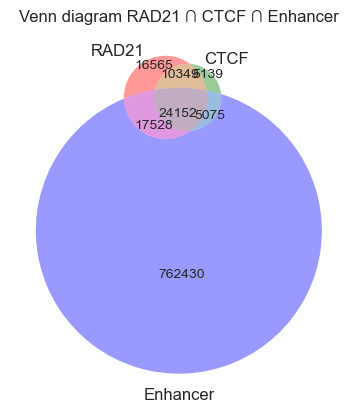

In [12]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# Totali
rad21 = 68594
ctcf = 44715
enh = 809185

# Intersezioni
rad21_ctcf = 34501
rad21_enh = 41680
ctcf_enh = 29227
triple = 24152

# Calcolo delle sezioni uniche e doppie correggendo il triplo
rad21_only = rad21 - rad21_ctcf - rad21_enh + triple
ctcf_only = ctcf - rad21_ctcf - ctcf_enh + triple
enh_only = enh - rad21_enh - ctcf_enh + triple

rad21_ctcf_only = rad21_ctcf - triple
rad21_enh_only = rad21_enh - triple
ctcf_enh_only = ctcf_enh - triple

# Creazione Venn
venn3(
    subsets=(rad21_only, ctcf_only, rad21_ctcf_only,
             enh_only, rad21_enh_only, ctcf_enh_only,
             triple),
    set_labels=('RAD21', 'CTCF', 'Enhancer')
)

plt.title("Venn diagram RAD21 ∩ CTCF ∩ Enhancer")
plt.show()


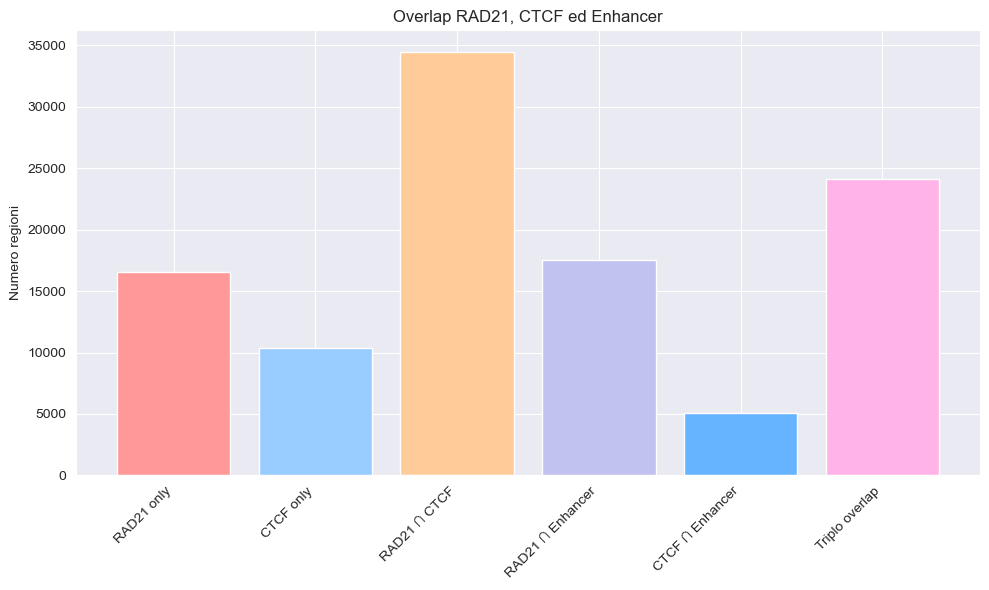

In [13]:
import matplotlib.pyplot as plt

# Dati
labels = [
    "RAD21 only",
    "CTCF only",
    "RAD21 ∩ CTCF",
    "RAD21 ∩ Enhancer",
    "CTCF ∩ Enhancer",
    "Triplo overlap"
]
values = [16565, 10349, 34501, 17528, 5075, 24152]

plt.figure(figsize=(10,6))
bars = plt.bar(labels, values, color=["#ff9999","#99ccff","#ffcc99","#c2c2f0","#66b3ff","#ffb3e6"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Numero regioni")
plt.title("Overlap RAD21, CTCF ed Enhancer")
plt.tight_layout()
plt.show()


Top 5 motivi significativi (RAD21-only):
            Target_ID  p-value  q-value  Overlap
GATA4_HUMAN.H11MO.0.A 0.000005 0.003654      6.0
 TAL1_HUMAN.H11MO.0.A 0.000013 0.003822      6.0
GATA6_HUMAN.H11MO.0.A 0.000014 0.003822      6.0
GATA3_HUMAN.H11MO.0.A 0.000027 0.005315      6.0
GATA1_HUMAN.H11MO.0.A 0.000041 0.006549      6.0


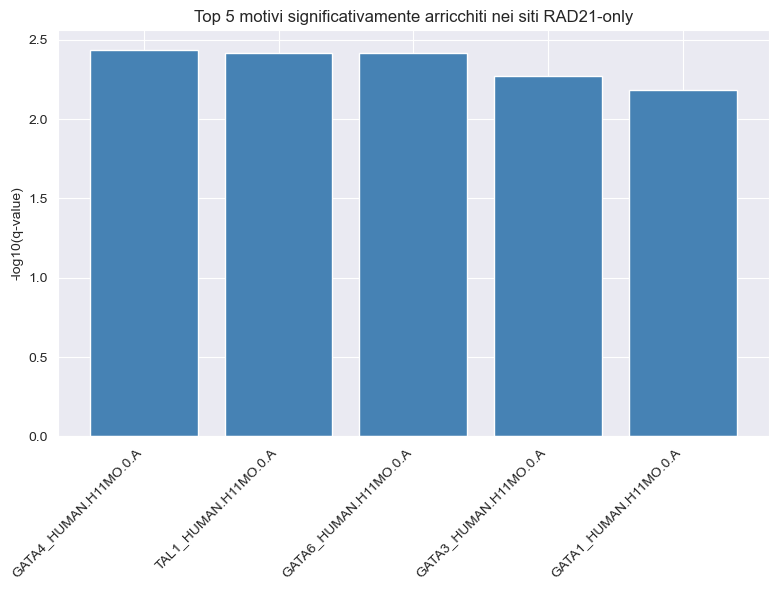

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Carica il file TomTom RAD21-only
file_path = r"D:\SYSTEMS BIOLOGY\tomtomrad21only.tsv"
df = pd.read_csv(file_path, sep="\t")

# Filtra i match significativi (q-value < 0.05) e ordina
df_sig = df[df["q-value"] < 0.05].sort_values("q-value")

# Seleziona solo i primi 5
top5 = df_sig.head(5)[["Target_ID", "p-value", "q-value", "Overlap"]]

# Mostra la tabella
print("Top 5 motivi significativi (RAD21-only):")
print(top5.to_string(index=False))

# Crea il barplot
plt.figure(figsize=(8,6))
plt.bar(top5["Target_ID"], -np.log10(top5["q-value"]), color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.ylabel("-log10(q-value)")
plt.title("Top 5 motivi significativamente arricchiti nei siti RAD21-only")
plt.tight_layout()
plt.show()


Top 5 motivi significativi (RAD21-only):
            Target_ID      p-value      q-value  Overlap
 CTCF_HUMAN.H11MO.0.A 9.895970e-21 7.857100e-18     15.0
CTCFL_HUMAN.H11MO.0.A 1.655910e-10 6.573720e-08     15.0
 CTCF_HUMAN.H11MO.0.A 5.337620e-07 4.221570e-04      7.0
ZN502_HUMAN.H11MO.0.C 2.480310e-06 1.976460e-03      8.0
SMCA5_HUMAN.H11MO.0.C 1.666890e-05 6.641380e-03      8.0


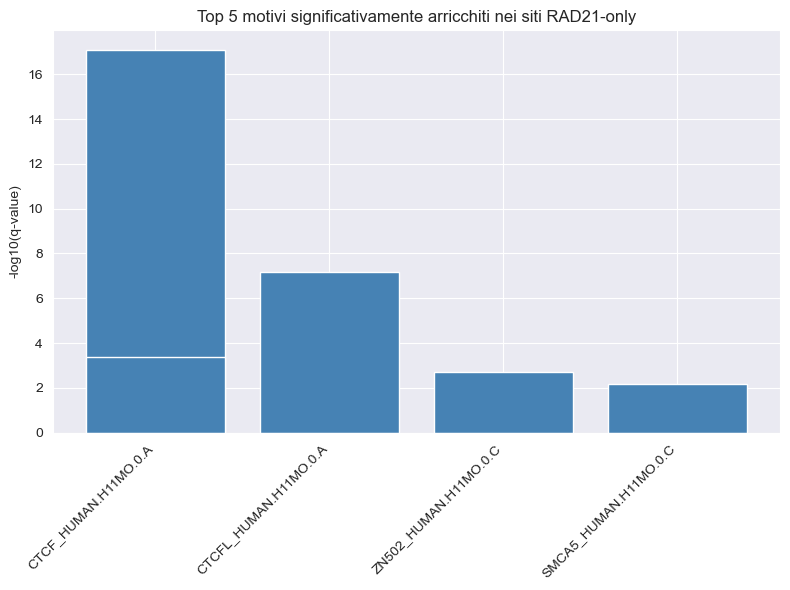

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Carica il file TomTom RAD21-only
file_path = r"D:\SYSTEMS BIOLOGY\tomtomRAD21CTCF.tsv"
df = pd.read_csv(file_path, sep="\t")

# Filtra i match significativi (q-value < 0.05) e ordina
df_sig = df[df["q-value"] < 0.05].sort_values("q-value")

# Seleziona solo i primi 5
top5 = df_sig.head(5)[["Target_ID", "p-value", "q-value", "Overlap"]]

# Mostra la tabella
print("Top 5 motivi significativi (RAD21-only):")
print(top5.to_string(index=False))

# Crea il barplot
plt.figure(figsize=(8,6))
plt.bar(top5["Target_ID"], -np.log10(top5["q-value"]), color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.ylabel("-log10(q-value)")
plt.title("Top 5 motivi significativamente arricchiti nei siti RAD21-only")
plt.tight_layout()
plt.show()
